# Assignment 1: Geometry of PCA  

In [3]:
#imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [55]:
#Helper functions

#Generate 2D correlated data
def generate_correlated_data(n=500, mean=(0, 0), cov=None, seed=0):
    rng = np.random.default_rng(seed)
    if cov is None:
        cov = np.array([[3.0, 2.7], [2.7, 3.0]])
    return rng.multivariate_normal(mean, cov, size=n)

#Normalize a vector to unit length
def unit(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

#Project points onto a direction, returning both the scalar projections and the projected coordinates
def project_points(X, direction):
    d = unit(direction)
    scalars = X @ d
    projected = np.outer(scalars, d)
    return scalars, projected

#Compute the principal component (eigenvector of covariance with largest eigenvalue) and return it along with the eigenvalue and covariance matrix
def principal_component(X):
    cov = np.cov(X, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    idx = np.argmax(vals)
    return vecs[:, idx], vals[idx], cov

#Summarize total variance, projected variance, and explained ratio for a given set of scalars and original data
def summarize_variance(X, scalars):
    total_var = np.trace(np.cov(X, rowvar=False))
    proj_var = np.var(scalars, ddof=0)
    return total_var, proj_var, proj_var / total_var

#Plot original data and projections for both manual and PCA directions
def plot_projection(X, d_manual, d_pca, scalars_manual, proj_manual, scalars_pca, proj_pca):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(X[:, 0], X[:, 1], alpha=0.4, label='Original data')
    axes[0].scatter(proj_manual[:, 0], proj_manual[:, 1], c='C1', alpha=0.6, label='Projection (manual)')
    line_pts = np.vstack([ -6 * unit(d_manual), 6 * unit(d_manual)])
    axes[0].plot(line_pts[:, 0], line_pts[:, 1], 'C1--', label='Manual direction')
    axes[0].set_title('Manual projection')
    axes[0].axis('equal')
    axes[0].legend()

    axes[1].scatter(X[:, 0], X[:, 1], alpha=0.4, label='Original data')
    axes[1].scatter(proj_pca[:, 0], proj_pca[:, 1], c='C2', alpha=0.6, label='Projection (PCA)')
    line_pts = np.vstack([ -6 * unit(d_pca), 6 * unit(d_pca)])
    axes[1].plot(line_pts[:, 0], line_pts[:, 1], 'C2--', label='PCA direction')
    axes[1].set_title('PCA projection')
    axes[1].axis('equal')
    axes[1].legend()

    fig.suptitle('2D data and projections')
    plt.tight_layout()
    plt.show()

In [62]:
# Execution: generate data, project, compare, and plot
X = generate_correlated_data(n=500, seed=42)

manual_dir = np.array([1.0, 0.4])
scalars_m, proj_m = project_points(X, manual_dir)

pca_dir, pca_eigval, cov = principal_component(X)
scalars_p, proj_p = project_points(X, pca_dir)

total_var_m, proj_var_m, ratio_m = summarize_variance(X, scalars_m)
total_var_p, proj_var_p, ratio_p = summarize_variance(X, scalars_p)

print('Covariance matrix:\n', cov)
print('\nManual direction (unit):', unit(manual_dir))
print('Projected variance (manual):', proj_var_m)
print('Explained ratio (manual): {:.3f}'.format(ratio_m))

print('\nPCA direction (unit):', unit(pca_dir))
print('Leading eigenvalue (variance along PCA):', pca_eigval)
print('Projected variance (PCA):', proj_var_p)
print('Explained ratio (PCA): {:.3f}'.format(ratio_p))



Covariance matrix:
 [[3.13894702 2.65652809]
 [2.65652809 2.7593503 ]]

Manual direction (unit): [0.92847669 0.37139068]
Projected variance (manual): 4.9088398316363895
Explained ratio (manual): 0.832

PCA direction (unit): [-0.73186897 -0.68144539]
Leading eigenvalue (variance along PCA): 5.612448284250705
Projected variance (PCA): 5.601223387682205
Explained ratio (PCA): 0.950


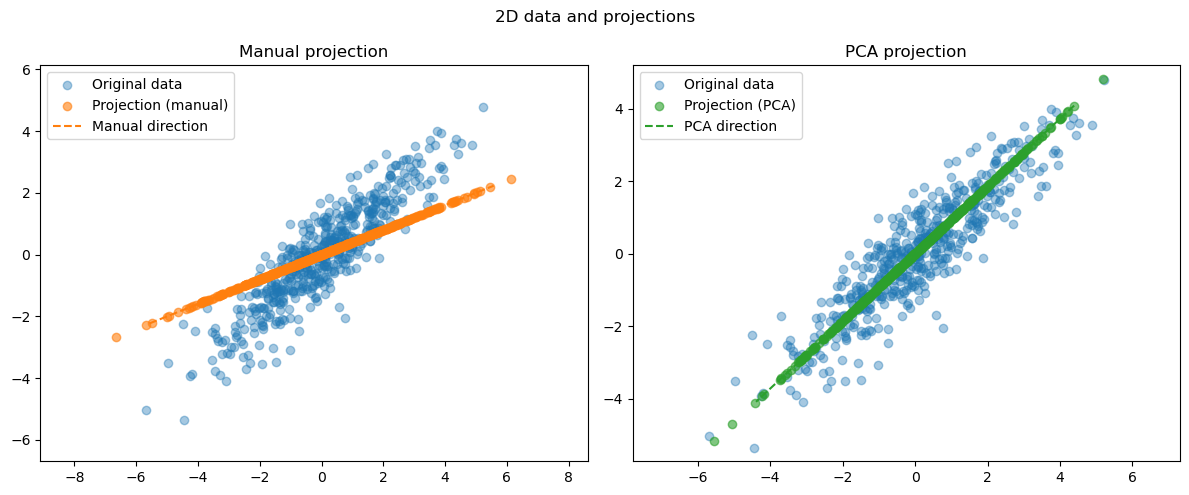

In [61]:
#VIsualize the original data and projections
plot_projection(X, manual_dir, pca_dir, scalars_m, proj_m, scalars_p, proj_p)


In [63]:
#Conclusion: PCA should preserve maximum variance, so we expect proj_var_p >= proj_var_m
if proj_var_p >= proj_var_m:
    print('\nConclusion: PCA direction preserves maximum variance.')
else:
    print('\nConclusion: Manual direction preserved more variance (unexpected).')


Conclusion: PCA direction preserves maximum variance.


# Assignment 2: Eigenvalues = Variance

In [ ]:
# Eigenvalues = variance demonstration
# Create dataset, compute covariance, find eigenpairs, verify direction of max variance, and plot eigenvectors.
X = generate_correlated_data(n=500, seed=7)
mean = X.mean(axis=0)
X_centered = X - mean

cov = np.cov(X_centered, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print('Covariance matrix:\n', cov)
print('\nEigenvalues (descending):', eigvals)
print('Eigenvectors (columns):\n', eigvecs)

proj_vars = [np.var(X_centered @ eigvecs[:, i], ddof=0) for i in range(eigvecs.shape[1])]
print('\nProjected variances along eigenvectors:', proj_vars)
print('\nLargest eigenvalue:', eigvals[0])
print('Variance along first eigenvector:', proj_vars[0])
print('Matches largest eigenvalue (within tolerance):', np.allclose(proj_vars[0], eigvals[0], atol=1e-8))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], alpha=0.4, label='Data')
for i in range(eigvecs.shape[1]):
    v = eigvecs[:, i]
    start, end = mean - 4 * v, mean + 4 * v
    ax.plot([start[0], end[0]], [start[1], end[1]], linestyle='--' if i == 0 else ':', linewidth=2,
            label=f'eigvec {i+1} (λ={eigvals[i]:.2f})')
ax.set_title('2D data with covariance eigenvectors')
ax.set_aspect('equal')
ax.legend()
plt.show()
